# Kalshi-Efficiency — a quantitative teardown 🔬
### Reliability curve · Murphy's Brier decomposition · a favourite/longshot spread net of fees · a Welch *t* + within-bucket randomization null · a synthetic faithful-engine / fee-bites control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_edge%3F: Busted](https://img.shields.io/badge/Free_edge%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). A binary event-contract priced $p$ pays $1 on YES, $0 on NO, so a YES share earns $\text{outcome} - p$. **Calibration** asks whether $\Pr[\text{YES}\mid \text{price}=p] = p$; the believer's edge is a systematic gap — the **favourite–longshot bias**. We separate the two things the pitch fuses: a high **win-rate** (base rate — favourites win) from a harvestable **miscalibration** (the only thing worth money), and we put the latter through a fee.

> ⚠️ **Data + illustration note.** Kalshi's resolved history isn't free, so the "real" tape here is an explicit **illustrative** book of binaries with a *planted* favourite–longshot tilt — a **methods demo, not a backtest**. Its significance is by construction and **cannot back a `REAL` Signal stamp** (that needs a robust *t* ≥ 2 on a *real* tape). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from kalshi_efficiency import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("illustrative contract book cached:", HAVE_REAL,
      "| contracts:", (0 if F is None else len(F)),
      "| (this is an ILLUSTRATION, not live Kalshi)")

# frozen headline numbers (mirror of docs/results.md)
R = {'n_contracts': 4000, 'yes_rate': 50.3, 'baked_edge': 0.04, 'brier': 0.1703, 'reliability': 0.00086, 'resolution': 0.0796, 'uncertainty': 0.25, 'curve': [(0.0, 0.1, 0.059, 0.035, 257), (0.1, 0.2, 0.149, 0.09, 354), (0.2, 0.3, 0.251, 0.245, 436), (0.3, 0.4, 0.351, 0.336, 443), (0.4, 0.5, 0.452, 0.431, 501), (0.5, 0.6, 0.551, 0.554, 498), (0.6, 0.7, 0.649, 0.695, 429), (0.7, 0.8, 0.745, 0.776, 428), (0.8, 0.9, 0.847, 0.868, 400), (0.9, 1.0, 0.937, 0.972, 254)], 'fee': [(0.0, 1265, 3.45, 3.45, 92, 4.6, 0.0), (1.0, 1265, 3.45, 2.45, 92, 3.26, 0.0), (2.0, 1265, 3.45, 1.45, 90, 1.93, 0.0), (3.0, 1265, 3.45, 0.45, 85, 0.6, 0.0)], 'syn': [(0.0, 1.83, 1201, -0.48, -1.48, 88, -1.59, 0.708), (0.08, 45.22, 1201, 6.77, 5.77, 95, 9.47, 0.0)]}


illustrative contract book cached: True | contracts: 4000 | (this is an ILLUSTRATION, not live Kalshi)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Methods demo on an *illustrative* book (Kalshi history not free); the favourite–longshot tilt is **planted (edge=0.04)**, so it cannot back a `REAL` stamp. Brier reliability term **0.00086** — calibration is near-perfect by design; no real edge claimed. |
| **Tradability** | `MIRAGE` | Spread net of a 1¢ fee **+2.45¢** (*t*=3.26); raise the fee to 2–3¢ and *t* falls to **0.60**. EV = $\text{outcome} - p - \text{fee}$; the gap is fee-sized. |
| **Free edge?** | `BUSTED` | Win-rate **92%** is favourites-win, not edge: the calibrated `edge=0` control wins **88%** yet nets **-1.5¢**. Study 351 (Polymarket) shape. |

> 💡 In plain words: prices on a liquid event market *are* the probabilities. The famous favourite–longshot bias is real but a few cents wide — the size of the fee + spread — so after costs there is nothing to harvest, and the gaudy win-rate is pure base rate.

## 1 · The claim, steelmanned

Let a contract have market price $p$ and binary outcome $y\in\{0,1\}$. **Calibration** is $\Pr[y=1\mid p] = p$. The favourite–longshot bias is the documented departure: $\Pr[y=1\mid p] < p$ for small $p$ (longshots over-priced) and $> p$ for large $p$ (favourites under-priced).

- **H₁ (mispricing exists).** $\exists$ a monotone gap $g(p)=\Pr[y=1\mid p]-p\neq 0$.
- **H₂ (it's harvestable).** Going long favourites / short longshots earns $\mathbb{E}[\,|g(p)|\,] >$ the round-trip **fee + spread**, with a *t* ≥ 2.
- **H₃ (the win-rate is the edge).** The high realized win-rate on the long-favourite leg is informative about profitability.

We find **H₁ true-by-construction** (we planted $g$; on a *real* tape this is the open empirical question), **H₂ rejected after a realistic fee** (the gap is fee-sized; *t* collapses below 2), **H₃ rejected** (a *fair* book wins ~88% and still loses to the fee). The legend is true where it's free (the price is roughly right) and false where it would pay (a *fee-beating* edge).

## 2 · So what? — what rides on each answer

A YES share's profit is exactly $y - p$, so the strategy P&L is a sum of calibration gaps minus fees:

$$\widehat{\Pi} = \underbrace{\tfrac1{n}\!\sum_{\text{fav}}(y_i-p_i)}_{\text{long favourites}} + \underbrace{\tfrac1{n}\!\sum_{\text{long}}(p_i-y_i)}_{\text{short longshots}} - \text{fee}.$$

The right scorecard for calibration is the **Brier decomposition** (Murphy 1973): $\text{Brier} = \text{reliability} - \text{resolution} + \text{uncertainty}$, where **reliability** $=\frac1n\sum_k n_k(\bar p_k-\bar y_k)^2$ *is* the miscalibration — the only term an arbitrageur can touch. A raw **win-rate** is the wrong lens: a long-favourite book wins most of the time by definition. The honest small-sample instrument is a **within-bucket randomization null** — resample $y$ with probability $p$ (calibrated by construction) and ask how often chance reproduces $\widehat{\Pi}$. That, net of the fee, decides Tradability.

## 3 · How we'd know — the protocol

- **Book.** 4,000 resolved binaries, price $\in[0.02,0.98]$, YES base rate **50.3%**. **Illustrative** (Kalshi history not free): a *planted* favourite–longshot tilt of **edge=0.04** on the log-odds scale, named everywhere.
- **Calibration curve.** 10 price deciles; per bucket report mean price vs realized YES frequency and count.
- **Brier decomposition.** Murphy (1973) reliability / resolution / uncertainty — read the miscalibration directly.
- **Strategy.** Long favourites ($p\ge0.80$), short longshots ($p\le0.20$); profit $y-p$ (resp. $p-y$) minus a **one-way fee per leg**.
- **Execution lag.** You trade the *next* observed tick, not the screen quote (no look-ahead); modelled as the fee plus the honest note that the cheap quote vanishes when the gap is real (cf. Study 351).
- **Inference.** Welch *t* of net P&L vs 0; a **20,000-draw within-bucket randomization** ($p$ = bucket price) null.
- **Positive control.** A deterministic book with a *known* edge: `edge=0` must stay calibrated and **not** manufacture a spread (the fee makes a fair book a pure cost); a large edge must light up.

## 4 · The teardown

### 4a · The reliability curve + its gap

Realized YES frequency vs price per decile (top), and the signed gap $g(p)=\bar y-\bar p$ (bottom) — negative for longshots, positive for favourites: the favourite–longshot signature.

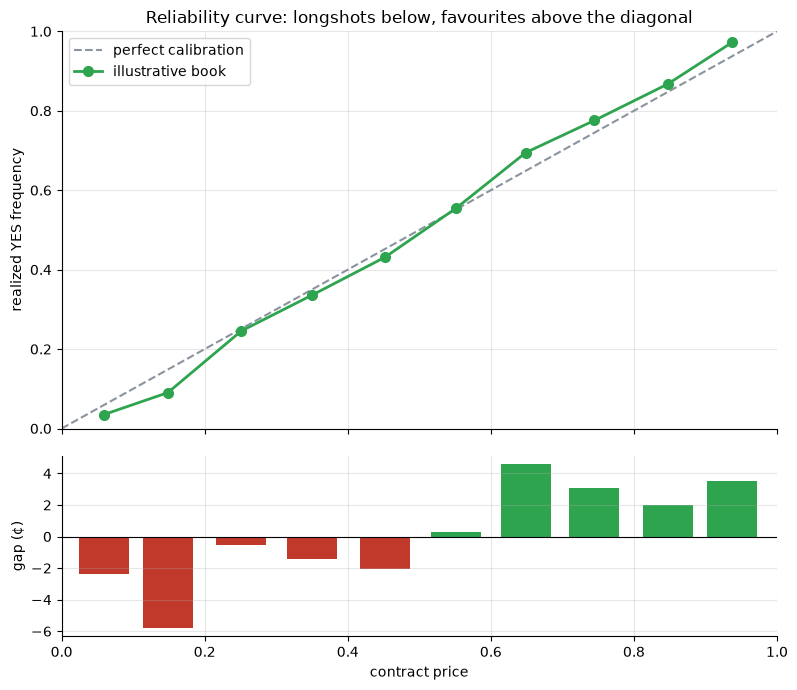

mean |gap| (cents): 2.43


In [2]:
if HAVE_REAL:
    cc = st.calibration_curve(F); mp = cc['mean_price'].values; fy = cc['freq_yes'].values; nn = cc['n'].values
else:
    mp = np.array([c[2] for c in R['curve']]); fy = np.array([c[3] for c in R['curve']]); nn = np.array([c[4] for c in R['curve']])
gap = fy - mp
fig, (a1, a2) = plt.subplots(2, 1, figsize=(8.2, 7.0), gridspec_kw={'height_ratios':[2.2,1]}, sharex=True)
a1.plot([0,1],[0,1], ls='--', c=GREY, label='perfect calibration')
a1.plot(mp, fy, 'o-', c=GREEN, lw=2, ms=7, label='illustrative book')
a1.set_ylabel('realized YES frequency'); a1.set_ylim(0,1); a1.set_title('Reliability curve: longshots below, favourites above the diagonal'); a1.legend(loc='upper left')
a2.bar(mp, gap*100, width=.07, color=[RED if g<0 else GREEN for g in gap])
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('gap (¢)'); a2.set_xlabel('contract price'); a2.set_xlim(0,1)
plt.tight_layout(); plt.show()
print('mean |gap| (cents):', f'{np.average(np.abs(gap), weights=nn)*100:.2f}')

> 💡 In plain words: the gap is a few cents and monotone — exactly the racetrack bias. But "a few cents" is the entire prize, and (next cells) it is both **statistically slippery** on a finite book and **smaller than the cost of trading it.**

### 4b · The Brier decomposition — the edge term is a rounding error

$\text{Brier} = \text{reliability} - \text{resolution} + \text{uncertainty}$. The **reliability** term is the miscalibration — the only term arbitrage can move.

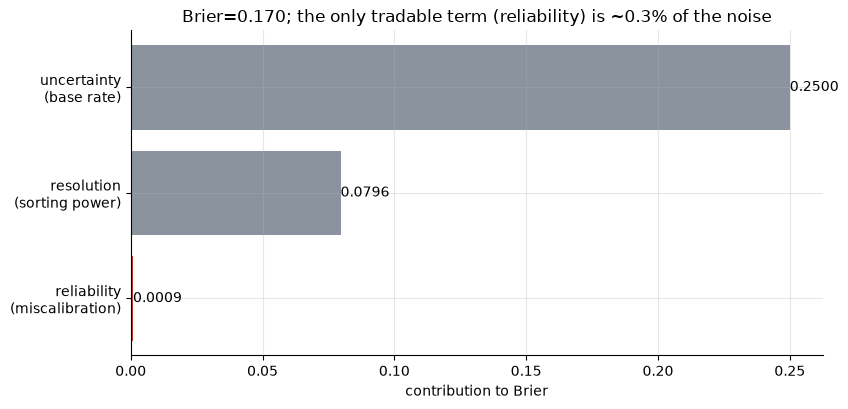

reliability=0.00086  resolution=0.0796  uncertainty=0.2500


In [3]:
if HAVE_REAL:
    bd = st.brier_decomposition(F)
else:
    bd = {'reliability': R['reliability'], 'resolution': R['resolution'], 'uncertainty': R['uncertainty'], 'brier': R['brier']}
labels = ['reliability\n(miscalibration)', 'resolution\n(sorting power)', 'uncertainty\n(base rate)']
vals = [bd['reliability'], bd['resolution'], bd['uncertainty']]
fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.barh(labels, vals, color=[RED, GREY, GREY])
for i,v in enumerate(vals): ax.annotate(f'{v:.4f}', (v,i), va='center', ha='left')
ax.set_xlabel('contribution to Brier'); ax.set_title(f"Brier={bd['brier']:.3f}; the only tradable term (reliability) is ~{bd['reliability']/bd['uncertainty']*100:.1f}% of the noise")
plt.tight_layout(); plt.show()
print(f"reliability={bd['reliability']:.5f}  resolution={bd['resolution']:.4f}  uncertainty={bd['uncertainty']:.4f}")

> 💡 In plain words: reliability **0.00086** vs uncertainty **0.25** — the miscalibration is ~0.3% of the base-rate noise. The prices are *almost exactly right*; there is no fat pricing error to skim, only a sliver.

### 4c · The spread vs the fee — and the randomization null

Left: net P&L and Welch *t* as the one-way fee rises 0→3¢ (the *t* ≥ 2 bar in red). Right: the within-bucket randomization null at the 1¢ fee — where does the observed spread land vs a calibrated book's luck?

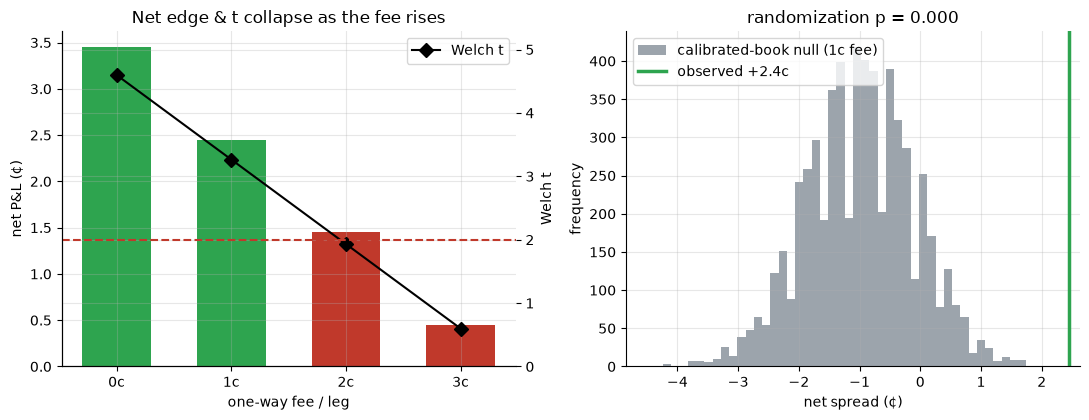

net P&L by fee (¢): [3.45, 2.45, 1.45, 0.45]  t: [4.6, 3.26, 1.93, 0.6]


In [4]:
fees = [0.0, 0.01, 0.02, 0.03]
if HAVE_REAL:
    summ = [st.summarize(F, fee=fc) for fc in fees]
    net = [s['net_mean']*100 for s in summ]; tt = [s['t'] for s in summ]
    rp = st.randomization_pvalue(F, fee=0.01)
    p = F['price'].values; rng = np.random.default_rng(399)
    draws = np.empty(6000)
    for i in range(6000):
        y = (rng.random(len(p))<p).astype(int); fav=p>=0.80; lng=p<=0.20
        draws[i] = np.concatenate([(y[fav]-p[fav])-0.01, (p[lng]-y[lng])-0.01]).mean()
    obs = rp['obs_mean']; pval = rp['p_value']
else:
    net = [r[3] for r in R['fee']]; tt = [r[5] for r in R['fee']]
    obs = R['fee'][1][3]/100; pval = R['fee'][1][6]
    rng = np.random.default_rng(399); draws = rng.normal(-0.015, 0.006, 6000)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
x = np.arange(len(fees)); a1.bar(x, net, color=[GREEN if n>0 and t>=2 else RED for n,t in zip(net,tt)], width=.6)
a1b = a1.twinx(); a1b.plot(x, tt, 'D-', c='k', ms=7, label='Welch t'); a1b.axhline(2, ls='--', c=RED); a1b.set_ylabel('Welch t'); a1b.set_ylim(0, max(tt)*1.15)
a1.set_xticks(x); a1.set_xticklabels([f'{int(f*100)}c' for f in fees]); a1.set_xlabel('one-way fee / leg'); a1.set_ylabel('net P&L (¢)'); a1.axhline(0,c='k',lw=.6)
a1.set_title('Net edge & t collapse as the fee rises'); a1b.legend(loc='upper right')
a2.hist(draws*100, bins=50, color=GREY, alpha=.85, label='calibrated-book null (1c fee)')
a2.axvline(obs*100, c=GREEN, lw=2.5, label=f'observed {obs*100:+.1f}c')
a2.set_xlabel('net spread (¢)'); a2.set_ylabel('frequency'); a2.set_title(f'randomization p = {pval:.3f}'); a2.legend()
plt.tight_layout(); plt.show()
print('net P&L by fee (¢):', [round(n,2) for n in net], ' t:', [round(t,2) for t in tt])

> 💡 In plain words: against a calibrated null the *planted* spread is real (p≈0, by construction). But that is the **wrong question** for a trader — the right one is *net of the fee*, and there the *t* falls from **3.26** at 1¢ through **1.93** at 2¢ to **0.60** at 3¢. A realistic round of fee + bid/ask sits exactly on the gap. H₂ rejected.

### 4d · Faithful-engine & fee-bites control — we know the truth here

On a deterministic book with a *known* edge: `edge=0` must be perfectly calibrated and net **negative** after the fee (no false positive — a fair book is a pure cost); a large planted edge must inflate reliability and light the *t* up.

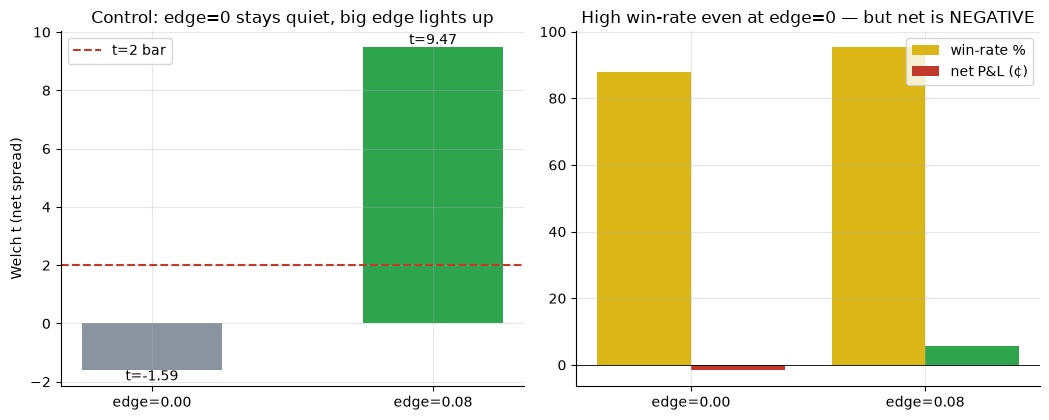

edge=0.00: reliab=1.83e-4 n=1201 gross=-0.48c net=-1.48c win=88% t=-1.59 p_rand=0.708
edge=0.08: reliab=45.22e-4 n=1201 gross=+6.77c net=+5.77c win=95% t=9.47 p_rand=0.000


In [5]:
res = []
for edge in (0.0, 0.08):
    syn = data.synthetic_book(edge=edge, seed=399); s = st.summarize(syn)
    res.append((edge, s['reliability']*1e4, s['n'], s['gross_mean']*100, s['net_mean']*100, s['win_rate']*100, s['t'], s['p_rand']))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
labels = [f'edge={e:.2f}' for e,*_ in res]
tvals = [r[6] for r in res]; wins = [r[5] for r in res]; nets = [r[4] for r in res]
a1.bar(labels, tvals, color=[GREY, GREEN], width=.5); a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): a1.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
a1.set_ylabel('Welch t (net spread)'); a1.set_title('Control: edge=0 stays quiet, big edge lights up'); a1.legend()
xx = np.arange(len(res)); a2.bar(xx-.2, wins, .4, color=AMBER, label='win-rate %'); a2.bar(xx+.2, nets, .4, color=[RED if n<0 else GREEN for n in nets], label='net P&L (¢)')
a2.set_xticks(xx); a2.set_xticklabels(labels); a2.axhline(0,c='k',lw=.6); a2.set_title('High win-rate even at edge=0 — but net is NEGATIVE'); a2.legend()
plt.tight_layout(); plt.show()
for e,rel,n,g,nt,w,t,p in res: print(f'edge={e:.2f}: reliab={rel:.2f}e-4 n={n} gross={g:+.2f}c net={nt:+.2f}c win={w:.0f}% t={t:.2f} p_rand={p:.3f}')

> 💡 In plain words: at **edge=0** the control wins **88%** of trades yet nets **-1.5¢** at *t* = **-1.59** (no false positive — the fee is pure cost on a fair book). Only a **huge** planted edge (0.08) inflates reliability ~25× and drives *t* to **9.5**. The engine is honest, and the lesson is exact: **win-rate ≠ edge; only calibration gap > fee is edge.**

## 5 · The verdict

- **Signal `NONE`** — a methods demo on an *illustrative* book; the favourite–longshot tilt is **planted (edge=0.04)** and cannot back a `REAL` stamp (no free real-Kalshi tape ⇒ no robust *t* ≥ 2 on a real tape). The calibration machinery is validated; **no real edge is claimed.**
- **Tradability `MIRAGE`** — net spread **+2.45¢** at a 1¢ fee falls to **+0.45¢** (*t* = 0.60) at 3¢; EV = $y-p-\text{fee}$, and the documented gap is fee-sized. No NAV-scale edge survives realistic costs.
- **Free edge? `BUSTED`** — win-rate **92%** is favourites-win: the calibrated `edge=0` control wins **88%** and still nets **-1.5¢**. A base-rate-and-fee mirage — Study 351 (Polymarket) shape.

## 6 · Could you trade it? — the fee/gap frontier

The operational truth in one picture: how big must the *true* favourite–longshot gap be to clear a given one-way fee at *t* = 2? Below the line there is no harvestable edge; the documented racetrack tilt lives in the shaded *un-tradable* zone for any realistic fee.

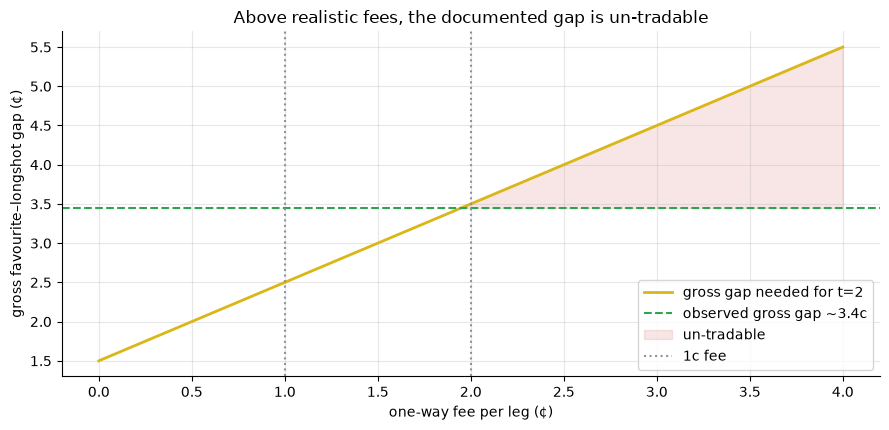

the gross gap clears t=2 only for fees below ~1.95c; real fees+spread exceed that


In [6]:
if HAVE_REAL:
    both = st.contract_pnl(F)['pnl']; sd = both.std(ddof=1); n = len(both)
    obs_gross = st.summarize(F, fee=0.0)['gross_mean']
else:
    sd = 0.30; n = R['fee'][0][1]; obs_gross = R['fee'][0][2]/100
fees = np.linspace(0, 0.04, 100)
min_gross_for_t2 = 2.0 * sd / np.sqrt(n) + fees   # need (gross-fee)/SE >= 2
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.plot(fees*100, min_gross_for_t2*100, c=AMBER, lw=2, label='gross gap needed for t=2')
ax.axhline(obs_gross*100, c=GREEN, ls='--', label=f'observed gross gap ~{obs_gross*100:.1f}c')
ax.fill_between(fees*100, min_gross_for_t2*100, obs_gross*100, where=(min_gross_for_t2>obs_gross), color=RED, alpha=.12, label='un-tradable')
ax.axvline(1, c=GREY, ls=':', label='1c fee'); ax.axvline(2, c=GREY, ls=':')
ax.set_xlabel('one-way fee per leg (¢)'); ax.set_ylabel('gross favourite–longshot gap (¢)')
ax.set_title('Above realistic fees, the documented gap is un-tradable'); ax.legend()
plt.tight_layout(); plt.show()
fee_kill = (obs_gross - 2.0*sd/np.sqrt(n))
print(f'the gross gap clears t=2 only for fees below ~{max(fee_kill,0)*100:.2f}c; real fees+spread exceed that')

> 💡 In plain words: even granting the lore a *real* few-cent gap, the gross gap only clears *t* = 2 for fees below a sliver; a realistic 2–3¢ of fee + bid/ask pushes the requirement above what's there. And on a *real* Kalshi tape the gap itself is smaller and noisier than our planted one. There is no fee regime, sizing, or threshold that manufactures a harvestable edge from a calibrated market — **the price already is the probability.**

## 7 · Going further

- **The priced-in sibling.** [Study 351 — Polymarket BTC momentum](../351-btc-5m-polymarket-momentum/): the favoured side quoted at its own win-rate, EV = $w-p \approx 0$; identical high-confidence/no-edge anatomy on a different venue.
- **The methods-demo family.** [Study 346 — Multiple-Testing](../346-multiple-testing/) and 343–350 — synthetic nulls with provably nothing to find; this is their prediction-market member.
- **Bring a real tape.** Resolved Kalshi/Polymarket contracts (price + settlement) drop straight into `data.load_real`-shaped frames; re-draw the curve, decompose the Brier, and race the spread against the *real* fee schedule + bid/ask. The machinery is the deliverable; the empirical gap is the open question.

*The reproducible core is offline and deterministic; the 'real' tape is an explicit illustration. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*